In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import curve_fit

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

def savefig(fig, name):
    fig.savefig(f'{name}.pdf', bbox_inches='tight')
    print(f'Zapisano {name}.pdf')

## 1. Wczytanie danych

In [91]:
weight_mass     = pd.read_csv('weight_mass.csv')
weight_diam     = pd.read_csv('weight_diameter.csv')
weight_thick    = pd.read_csv('weight_thickness.csv')
weight_dist     = pd.read_csv('weight_distance.csv')
rod_length      = pd.read_csv('rod_length.csv')
rod_mass        = pd.read_csv('rod_mass.csv')
vibrations      = pd.read_csv('vibrations.csv')
type1_vib       = pd.read_csv('type_1_normal_vibrations.csv')
type2_vib       = pd.read_csv('type_2_normal_vibrations.csv')
spring_dist     = pd.read_csv('spring_distance.csv')
rumble          = pd.read_csv('rumble_vibrations.csv')

# Przeliczenie jednostek: mm -> m, g -> kg
def mm2m(df, cols): df[cols] = df[cols] / 1000.0; return df
def g2kg(df, cols): df[cols] = df[cols] / 1000.0; return df

for df, cols in [
    (weight_diam,  ['d','u_d']),
    (weight_thick, ['h','u_h']),
    (weight_dist,  ['s','u_s']),
    (rod_length,   ['l','u_l']),
    (spring_dist,  ['s','u_s']),
    (rumble,       ['s','u_s']),
]:
    mm2m(df, cols)

for df, cols in [
    (weight_mass, ['m','u_m']),
    (rod_mass,    ['m','u_m']),
]:
    g2kg(df, cols)

print('Krążek - masa [kg]:'); display(weight_mass)
print('Krążek - średnica [m]:'); display(weight_diam)
print('Krążek - grubość [m]:'); display(weight_thick)
print('Krążek - odległość od osi [m]:'); display(weight_dist)
print('Pręt - długość [m]:'); display(rod_length)
print('Pręt - masa [kg]:'); display(rod_mass)
print('Odległość sprężyny (drgania normalne) [m]:'); display(spring_dist)
print('Drgania swobodne (T20 [s]):'); display(vibrations)
print('Drgania normalne typ 1 (T20 [s]):'); display(type1_vib)
print('Drgania normalne typ 2 (T20 [s]):'); display(type2_vib)
print('Dudnienia (T10 [s]):'); display(rumble)

Krążek - masa [kg]:


,weight,m,u_m
0,left,1.1645,0.0
1,right,1.1680,0.0


Krążek - średnica [m]:


,weight,d,u_d
0,left,0.0959,0.0001
1,right,0.0957,0.0001


Krążek - grubość [m]:


...

,T20,u_T20
0,39.01,0.8
1,38.85,0.8
2,38.74,0.8


Drgania normalne typ 2 (T20 [s]):


,T20,u_T20
0,31.76,0.8
1,31.66,0.8
2,31.86,0.8


Dudnienia (T10 [s]):


,s,u_s,T10,u_T10
0,0.4,0.01,185.47,0.8
1,0.4,0.01,187.80,0.8
2,0.4,0.01,186.62,0.8
3,0.5,0.01,119.12,0.8
4,0.5,0.01,119.56,0.8
5,0.5,0.01,119.19,0.8
6,0.6,0.01,83.02,0.8
7,0.6,0.01,81.77,0.8
8,0.6,0.01,81.96,0.8
9,0.7,0.01,61.10,0.8


## 2. Moment bezwładności J i moment kierujący D

**Krążek** (oś obrotu równoległa do średnicy, przesunięta o $s$ od środka masy):
$$J_\text{krążek} = m\left(\frac{d^2}{16} + \frac{h^2}{12}\right) + ms^2$$

**Pręt** (obrót na końcu):
$$J_\text{pręt} = \frac{1}{3}m_r l^2$$

**Moment kierujący:**
$$D = m_r g \frac{l}{2} + m_k g s$$

In [92]:
g = 9.81  # m/s^2

s_w  = weight_dist['s'].values[0]
us_w = weight_dist['u_s'].values[0]

results = {}
for side in ['left', 'right']:
    m_k  = weight_mass.loc[weight_mass['weight']==side, 'm'].values[0]
    um_k = weight_mass.loc[weight_mass['weight']==side, 'u_m'].values[0]
    d    = weight_diam.loc[weight_diam['weight']==side, 'd'].values[0]
    ud   = weight_diam.loc[weight_diam['weight']==side, 'u_d'].values[0]
    h    = weight_thick.loc[weight_thick['weight']==side, 'h'].values[0]
    uh   = weight_thick.loc[weight_thick['weight']==side, 'u_h'].values[0]
    m_r  = rod_mass.loc[rod_mass['rod']==side, 'm'].values[0]
    l    = rod_length.loc[rod_length['rod']==side, 'l'].values[0]

    # J_krazek
    J_cm  = m_k * (d**2/16 + h**2/12)
    J_k   = J_cm + m_k * s_w**2
    # propagacja niepewnosci J_krazek
    dJk_dd  = m_k * d/8
    dJk_dh  = m_k * h/6
    dJk_ds  = 2 * m_k * s_w
    uJ_k  = np.sqrt((dJk_dd*ud)**2 + (dJk_dh*uh)**2 + (dJk_ds*us_w)**2)

    # J_pret
    J_r   = m_r * l**2 / 3
    uJ_r  = 0.0  # u_l=0, u_m=0

    J     = J_k + J_r
    uJ    = uJ_k  # J_r exact

    # Moment kierujacy
    D     = m_r * g * l/2 + m_k * g * s_w
    dD_ds = m_k * g
    uD    = dD_ds * us_w

    # Czestotliwosc drgan wlasnych
    omega0_th = np.sqrt(D / J)
    T0_th     = 2*np.pi / omega0_th
    # propagacja: u_omega0^2 = (domega/dD * uD)^2 + (domega/dJ * uJ)^2
    uomega0   = 0.5/omega0_th * np.sqrt((uD/J)**2 + (D*uJ/J**2)**2)
    uT0_th    = 2*np.pi / omega0_th**2 * uomega0

    results[side] = dict(m_k=m_k, d=d, h=h, m_r=m_r, l=l,
                         J_k=J_k, uJ_k=uJ_k, J_r=J_r,
                         J=J, uJ=uJ, D=D, uD=uD,
                         omega0_th=omega0_th, uomega0_th=uomega0,
                         T0_th=T0_th, uT0_th=uT0_th)

for side, r in results.items():
    print(f"\n=== Wahadło {side} ===")
    print(f"  J_krążek = ({r['J_k']*1e4:.4f} ± {r['uJ_k']*1e4:.4f}) × 10⁻⁴ kg·m²")
    print(f"  J_pręt   = {r['J_r']*1e4:.4f} × 10⁻⁴ kg·m²")
    print(f"  J        = ({r['J']*1e4:.4f} ± {r['uJ']*1e4:.4f}) × 10⁻⁴ kg·m²")
    print(f"  D        = ({r['D']:.4f} ± {r['uD']:.4f}) N·m")
    print(f"  T₀_teor  = ({r['T0_th']:.4f} ± {r['uT0_th']:.4f}) s")


=== Wahadło left ===
  J_krążek = (11886.1423 ± 235.2290) × 10⁻⁴ kg·m²
  J_pręt   = 3680.5175 × 10⁻⁴ kg·m²
  J        = (15566.6598 ± 235.2290) × 10⁻⁴ kg·m²
  D        = (16.2474 ± 0.1142) N·m
  T₀_teor  = (1.9448 ± 0.0162) s

=== Wahadło right ===
  J_krążek = (11921.8391 ± 235.9360) × 10⁻⁴ kg·m²
  J_pręt   = 3680.5175 × 10⁻⁴ kg·m²
  J        = (15602.3566 ± 235.9360) × 10⁻⁴ kg·m²
  D        = (16.2821 ± 0.1146) N·m
  T₀_teor  = (1.9450 ± 0.0162) s


## 3. Drgania swobodne

In [93]:
def period_stats(T20_arr, u_T20_single):
    N        = len(T20_arr)
    u_A      = np.std(T20_arr, ddof=1) / np.sqrt(N)
    u_B      = u_T20_single
    u_T20    = np.sqrt(u_A**2 + u_B**2)
    T        = np.mean(T20_arr) / 20
    uT       = u_T20 / 20
    return T, uT, np.mean(T20_arr), u_T20

free = {}
for side in ['left', 'right']:
    sub      = vibrations[vibrations['pendulum'] == side]
    T20_arr  = sub['T20'].values
    u_single = sub['u_T20'].values[0]
    T, uT, T20_mean, uT20 = period_stats(T20_arr, u_single)
    free[side] = dict(T20_arr=T20_arr, T=T, uT=uT)
    print(f"Wahadło {side}: T₀ = ({T:.5f} ± {uT:.5f}) s  [z {len(T20_arr)} pomiarów T20]")

TL, uTL = free['left']['T'],  free['left']['uT']
TR, uTR = free['right']['T'], free['right']['uT']
diff    = abs(TL - TR)
u_diff  = np.sqrt(uTL**2 + uTR**2)
print(f"\n|T_L − T_R| = {diff*1e4:.1f}×10⁻⁴ s,  u_diff = {u_diff*1e4:.1f}×10⁻⁴ s")
print("Wahadła IDENTYCZNE" if diff < 2*u_diff else "Wahadła NIE są identyczne w granicach niepewności")

T0_exp  = (TL + TR) / 2
uT0_exp = 0.5 * u_diff

omega0_exp  = 2*np.pi / T0_exp
uomega0_exp = 2*np.pi / T0_exp**2 * uT0_exp

print(f"\nT₀_exp  = ({T0_exp:.5f} ± {uT0_exp:.5f}) s")
print(f"ω₀_exp  = ({omega0_exp:.5f} ± {uomega0_exp:.5f}) rad/s")
for side in ['left', 'right']:
    r = results[side]
    print(f"T₀_teor ({side}) = ({r['T0_th']:.5f} ± {r['uT0_th']:.5f}) s  |  "
          f"ω₀_teor = ({r['omega0_th']:.5f} ± {r['uomega0_th']:.5f}) rad/s")

Wahadło left: T₀ = (1.96945 ± 0.04002) s  [z 10 pomiarów T20]
Wahadło right: T₀ = (1.97000 ± 0.04007) s  [z 10 pomiarów T20]

|T_L − T_R| = 5.5×10⁻⁴ s,  u_diff = 566.3×10⁻⁴ s
Wahadła IDENTYCZNE

T₀_exp  = (1.96972 ± 0.02832) s
ω₀_exp  = (3.18988 ± 0.04586) rad/s
T₀_teor (left) = (1.94485 ± 0.01621) s  |  ω₀_teor = (3.23069 ± 0.02692) rad/s
T₀_teor (right) = (1.94500 ± 0.01622) s  |  ω₀_teor = (3.23043 ± 0.02694) rad/s


Zapisano rys_1_drgania_swobodne_surowe.pdf


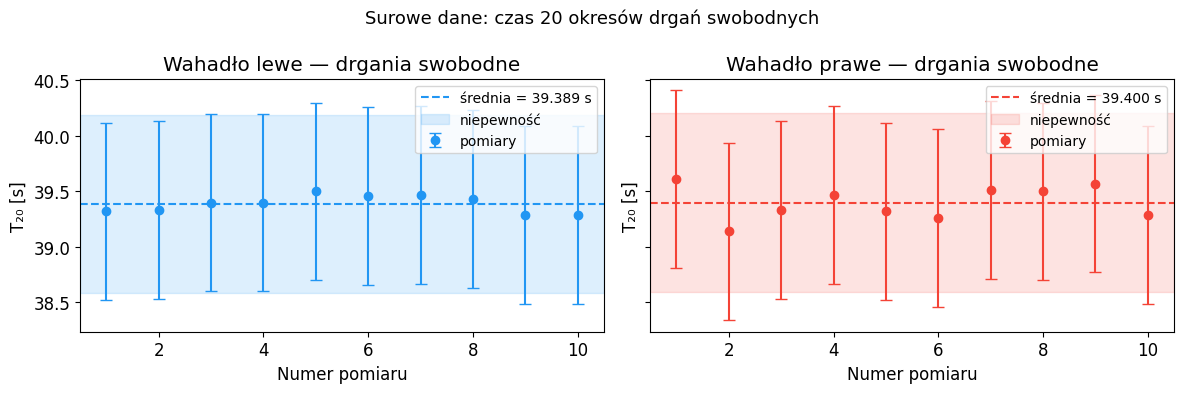

In [94]:
# --- Wykres 1: Surowe dane drgań swobodnych ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {'left': '#2196F3', 'right': '#F44336'}
names  = {'left': 'lewe', 'right': 'prawe'}

for ax, side in zip(axes, ['left', 'right']):
    T20_arr = free[side]['T20_arr']
    x = np.arange(1, len(T20_arr)+1)
    u_single = vibrations[vibrations['pendulum']==side]['u_T20'].values[0]
    ax.errorbar(x, T20_arr, yerr=u_single,
                fmt='o', color=colors[side], capsize=4, markersize=6,
                label='pomiary')
    ax.axhline(np.mean(T20_arr), color=colors[side], ls='--', lw=1.5,
               label=f'średnia = {np.mean(T20_arr):.3f} s')
    ax.fill_between([0.5, len(T20_arr)+0.5],
                    np.mean(T20_arr) - free[side]['uT']*20,
                    np.mean(T20_arr) + free[side]['uT']*20,
                    alpha=0.15, color=colors[side], label='niepewność')
    ax.set_title(f'Wahadło {names[side]} — drgania swobodne')
    ax.set_xlabel('Numer pomiaru')
    ax.set_ylabel('T₂₀ [s]')
    ax.legend(fontsize=10)
    ax.set_xlim(0.5, len(T20_arr)+0.5)

plt.suptitle('Surowe dane: czas 20 okresów drgań swobodnych', fontsize=13)
plt.tight_layout()
savefig(fig, 'rys_1_drgania_swobodne_surowe')
plt.show()

Zapisano rys_2_T0_eksp_vs_teoria.pdf


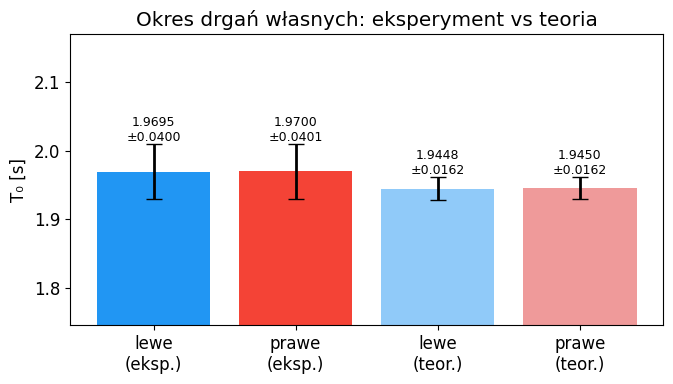

In [95]:
# --- Wykres 2: Porównanie T₀ eksperyment vs teoria ---
fig, ax = plt.subplots(figsize=(7, 4))

labels = ['lewe\n(eksp.)', 'prawe\n(eksp.)', 'lewe\n(teor.)', 'prawe\n(teor.)']
vals   = [TL, TR, results['left']['T0_th'], results['right']['T0_th']]
errs   = [uTL, uTR, results['left']['uT0_th'], results['right']['uT0_th']]
cols   = ['#2196F3', '#F44336', '#90CAF9', '#EF9A9A']

x = np.arange(len(labels))
bars = ax.bar(x, vals, yerr=errs, capsize=6, color=cols,
              error_kw={'elinewidth':2})
ymin = min(vals) - 5*max(errs)
ymax = max(vals) + 5*max(errs)
ax.set_ylim(ymin, ymax)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('T₀ [s]')
ax.set_title('Okres drgań własnych: eksperyment vs teoria')
for bar, v, u in zip(bars, vals, errs):
    ax.text(bar.get_x()+bar.get_width()/2, v+u+0.0002,
            f'{v:.4f}\n±{u:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
savefig(fig, 'rys_2_T0_eksp_vs_teoria')
plt.show()

## 4. Drgania normalne — wyznaczenie D_s metodą 1

In [96]:
J_avg  = (results['left']['J']  + results['right']['J'])  / 2
uJ_avg = (results['left']['uJ'] + results['right']['uJ']) / 2
D_avg  = (results['left']['D']  + results['right']['D'])  / 2
uD_avg = (results['left']['uD'] + results['right']['uD']) / 2

# srednia teoretyczna omega0 z J i D (niezalezna od pomiarow czasowych)
omega0_teor_avg  = np.sqrt(D_avg / J_avg)
uomega0_teor_avg = 0.5 / omega0_teor_avg * np.sqrt((uD_avg/J_avg)**2 + (D_avg*uJ_avg/J_avg**2)**2)

s_spring  = spring_dist['s'].values[0]
us_spring = spring_dist['u_s'].values[0]

T1_arr  = type1_vib['T20'].values
T2_arr  = type2_vib['T20'].values
u_T20_n = type1_vib['u_T20'].values[0]

T1, uT1, _, _ = period_stats(T1_arr, u_T20_n)
T2, uT2, _, _ = period_stats(T2_arr, u_T20_n)

omega1  = 2*np.pi / T1;   uomega1 = 2*np.pi / T1**2 * uT1
omega2  = 2*np.pi / T2;   uomega2 = 2*np.pi / T2**2 * uT2

K  = (omega2**2 - omega1**2) / 2
uK = 0.5 * np.sqrt((2*omega2*uomega2)**2 + (2*omega1*uomega1)**2)

Ds_m1  = K * J_avg
uDs_m1 = np.sqrt((uK*J_avg)**2 + (K*uJ_avg)**2)

print(f"T₁ (mod 1) = ({T1:.5f} ± {uT1:.5f}) s   ω₁ = ({omega1:.5f} ± {uomega1:.5f}) rad/s")
print(f"T₂ (mod 2) = ({T2:.5f} ± {uT2:.5f}) s   ω₂ = ({omega2:.5f} ± {uomega2:.5f}) rad/s")
print(f"K          = ({K:.4f} ± {uK:.4f}) rad²/s²")
print(f"Ds (met. 1, s={s_spring*1e3:.0f} mm) = ({Ds_m1:.5f} ± {uDs_m1:.5f}) N·m")

# Porownanie omega1 z omega0_teor (obie niezalezne: omega1 z pomiaru czasu, omega0_teor z J i D)
print(f"\nPorównanie ω₁ z ω₀_teor (z J i D):")
print(f"  ω₁_exp   = ({omega1:.5f} ± {uomega1:.5f}) rad/s")
print(f"  ω₀_teor  = ({omega0_teor_avg:.5f} ± {uomega0_teor_avg:.5f}) rad/s")
diff_o = abs(omega1 - omega0_teor_avg)
u_diff_o = np.sqrt(uomega1**2 + uomega0_teor_avg**2)
print(f"  Różnica: {diff_o:.5f} rad/s  (u = {u_diff_o:.5f} rad/s) — "
      + ("zgodne" if diff_o < 2*u_diff_o else "NIEZGODNE") + " w granicach 2σ")

T₁ (mod 1) = (1.94333 ± 0.04019) s   ω₁ = (3.23320 ± 0.06687) rad/s
T₂ (mod 2) = (1.58800 ± 0.04010) s   ω₂ = (3.95667 ± 0.09992) rad/s
K          = (2.6008 ± 0.4506) rad²/s²
Ds (met. 1, s=585 mm) = (4.05324 ± 0.70493) N·m

Porównanie ω₁ z ω₀_teor (z J i D):
  ω₁_exp   = (3.23320 ± 0.06687) rad/s
  ω₀_teor  = (3.23056 ± 0.02693) rad/s
  Różnica: 0.00264 rad/s  (u = 0.07209 rad/s) — zgodne w granicach 2σ


Zapisano rys_3_drgania_normalne_surowe.pdf


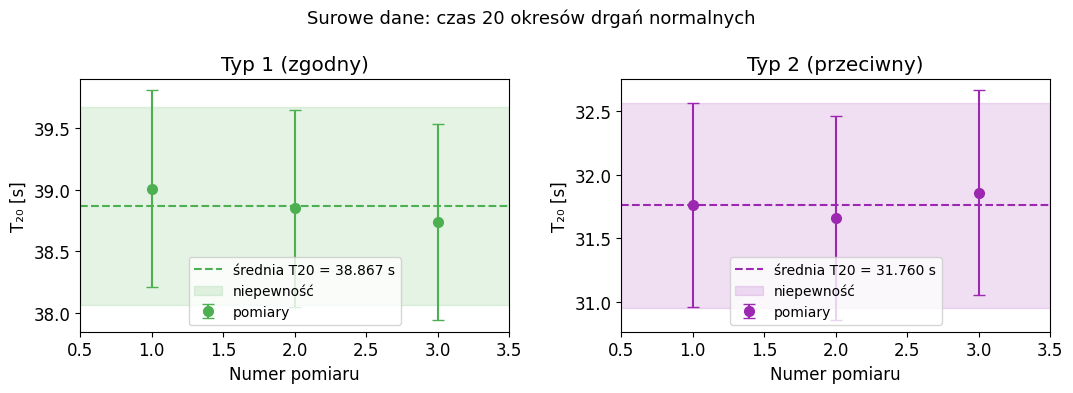

In [97]:
# --- Wykres 3: Surowe dane drgań normalnych ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, arr, label, color, T_mean, uT_val in [
    (axes[0], T1_arr, 'Typ 1 (zgodny)', '#4CAF50', T1, uT1),
    (axes[1], T2_arr, 'Typ 2 (przeciwny)', '#9C27B0', T2, uT2),
]:
    x = np.arange(1, len(arr)+1)
    ax.errorbar(x, arr, yerr=u_T20_n, fmt='o', color=color,
                capsize=4, markersize=7, label='pomiary')
    ax.axhline(T_mean*20, color=color, ls='--', lw=1.5,
               label=f'średnia T20 = {T_mean*20:.3f} s')
    ax.fill_between([0.5, len(arr)+0.5],
                    T_mean*20 - uT_val*20,
                    T_mean*20 + uT_val*20,
                    alpha=0.15, color=color, label='niepewność')
    ax.set_title(label)
    ax.set_xlabel('Numer pomiaru')
    ax.set_ylabel('T₂₀ [s]')
    ax.set_xlim(0.5, len(arr)+0.5)
    ax.legend(fontsize=10)

plt.suptitle('Surowe dane: czas 20 okresów drgań normalnych', fontsize=13)
plt.tight_layout()
savefig(fig, 'rys_3_drgania_normalne_surowe')
plt.show()

## 5. Dudnienia — surowe dane, D_s(s), dopasowanie i weryfikacja wzoru (1.4.16)

In [98]:
s_vals_unique = rumble['s'].unique()
rumble_stats  = []

for s_val in sorted(s_vals_unique):
    sub     = rumble[rumble['s'] == s_val]
    T10_arr = sub['T10'].values
    u_T10   = sub['u_T10'].values[0]
    us_val  = sub['u_s'].values[0]

    Td   = np.mean(T10_arr) / 10
    u_A  = np.std(T10_arr, ddof=1) / np.sqrt(len(T10_arr)) / 10
    u_B  = u_T10 / 10
    uTd  = np.sqrt(u_A**2 + u_B**2)

    omega_d  = 2*np.pi / Td
    uomega_d = 2*np.pi / Td**2 * uTd

    # D_s z wzoru (1.4.17): D_s = 4pi^2 * J / (Td * T0)
    Ds   = 4*np.pi**2 * J_avg / (Td * T0_exp)
    uDs  = Ds * np.sqrt((uTd/Td)**2 + (uT0_exp/T0_exp)**2 + (uJ_avg/J_avg)**2)

    rumble_stats.append(dict(s=s_val, us=us_val, T10_arr=T10_arr, u_T10=u_T10,
                             Td=Td, uTd=uTd,
                             omega_d=omega_d, uomega_d=uomega_d,
                             Ds=Ds, uDs=uDs))

df_rs = pd.DataFrame([{k: v for k, v in r.items() if k != 'T10_arr'} for r in rumble_stats])
display(df_rs[['s', 'us', 'Td', 'uTd', 'omega_d', 'uomega_d', 'Ds', 'uDs']].round(5))

,s,us,Td,uTd,omega_d,uomega_d,Ds,uDs
0,0.4,0.01,18.66300,0.10452,0.33667,0.00189,1.67365,0.03615
1,0.5,0.01,11.92900,0.08116,0.52672,0.00358,2.61844,0.05745
2,0.6,0.01,8.22500,0.08895,0.76391,0.00826,3.79762,0.08923
3,0.7,0.01,6.06767,0.08279,1.03552,0.01413,5.14785,0.12832
4,0.8,0.01,4.71867,0.08061,1.33156,0.02275,6.61954,0.17848
5,0.9,0.01,3.90533,0.08346,1.60887,0.03438,7.99814,0.23886


Zapisano rys_4_dudnienia_surowe.pdf


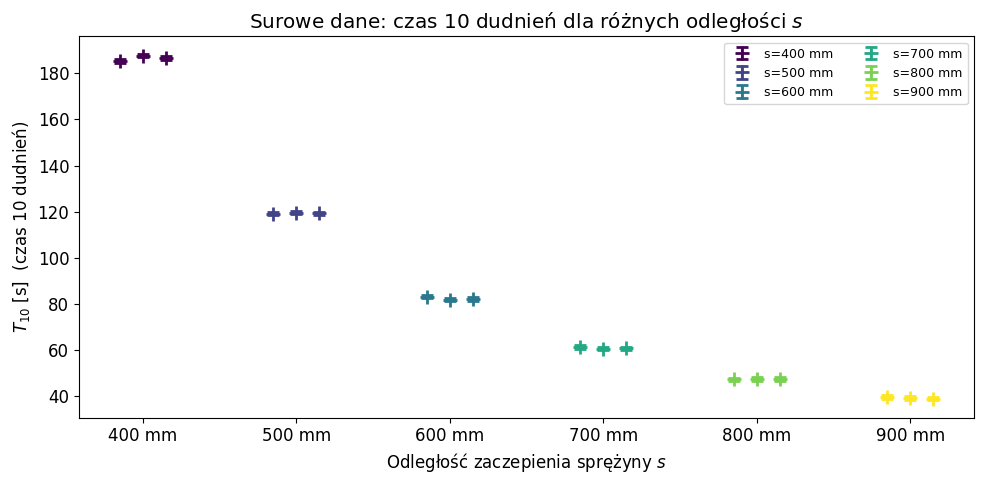

In [99]:
# --- Wykres 4: Surowe dane dudnień — T10 dla każdej odległości s ---
fig, ax = plt.subplots(figsize=(10, 5))

cmap     = plt.cm.viridis
s_sorted = sorted(s_vals_unique)
colors_s = [cmap(i / (len(s_sorted) - 1)) for i in range(len(s_sorted))]

for i, (stat, col) in enumerate(zip(rumble_stats, colors_s)):
    T10_arr = stat['T10_arr']
    x_off   = np.linspace(-0.15, 0.15, len(T10_arr))
    s_mm    = stat['s'] * 1000
    for j, t in enumerate(T10_arr):
        ax.errorbar(i + x_off[j], t, yerr=stat['u_T10'],
                    fmt='+', color=col, capsize=4, markersize=10,
                    markeredgewidth=2, elinewidth=1.5,
                    label=f's={s_mm:.0f} mm' if j == 0 else '')

ax.set_xticks(range(len(s_sorted)))
ax.set_xticklabels([f'{s*1000:.0f} mm' for s in s_sorted])
ax.set_xlabel('Odległość zaczepienia sprężyny $s$')
ax.set_ylabel('$T_{10}$ [s]  (czas 10 dudnień)')
ax.set_title('Surowe dane: czas 10 dudnień dla różnych odległości $s$')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
savefig(fig, 'rys_4_dudnienia_surowe')
plt.show()

In [ ]:
s_arr   = np.array([r['s']   for r in rumble_stats])
us_arr  = np.array([r['us']  for r in rumble_stats])
Ds_arr  = np.array([r['Ds']  for r in rumble_stats])
uDs_arr = np.array([r['uDs'] for r in rumble_stats])
Td_arr  = np.array([r['Td']  for r in rumble_stats])
uTd_arr = np.array([r['uTd'] for r in rumble_stats])

# --- Wykres 5a: Weryfikacja kwadratowej zależności — 1/Td vs s² ---
inv_Td  = 1.0 / Td_arr
u_invTd = uTd_arr / Td_arr**2
s2_arr  = s_arr**2
us2_arr = 2 * s_arr * us_arr

def lin_through_origin(x, a):
    return a * x

popt_lin, pcov_lin = curve_fit(lin_through_origin, s2_arr, inv_Td,
                                sigma=u_invTd, absolute_sigma=True)
a_lin  = popt_lin[0]
ua_lin = np.sqrt(pcov_lin[0, 0])
print(f"Dopasowanie 1/Td = a·s²:  a = ({a_lin:.4f} ± {ua_lin:.4f}) s⁻¹m⁻²")

s2_fine = np.linspace(0, (0.95)**2 * 1.05, 300)

fig, ax = plt.subplots(figsize=(8, 5))
for sv, usv, y, uy in zip(s2_arr, us2_arr, inv_Td, u_invTd):
    rect = mpatches.FancyBboxPatch(
        (sv - usv, y - uy), 2*usv, 2*uy,
        boxstyle='square,pad=0', linewidth=1.5,
        edgecolor='#1565C0', facecolor='#90CAF9', alpha=0.5)
    ax.add_patch(rect)
ax.plot(s2_arr, inv_Td, '+', color='#1565C0', markersize=10,
        markeredgewidth=2, zorder=5, label='dane eksperymentalne')
ax.plot(s2_fine, lin_through_origin(s2_fine, a_lin), '-', color='#E53935', lw=2,
        label=f'dopasowanie: $1/T_d = a\\cdot s^2$\n$a = ({a_lin:.4f} \\pm {ua_lin:.4f})$ s⁻¹m⁻²')
ax.fill_between(s2_fine,
                lin_through_origin(s2_fine, a_lin - ua_lin),
                lin_through_origin(s2_fine, a_lin + ua_lin),
                color='#E53935', alpha=0.15, label='niepewność dopasowania')
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
ax.set_xlabel('$s^2$ [m²]')
ax.set_ylabel('$1/T_d$ [s⁻¹]')
ax.set_title('Weryfikacja kwadratowej zależności $D_s \\propto s^2$\n'
             r'($D_s = ks^2$ i wzór (1.4.17) $\Rightarrow$ $1/T_d \propto s^2$)')
ax.legend(fontsize=10)
plt.tight_layout()
savefig(fig, 'rys_5a_kwadratowa_zaleznosc')
plt.show()

# --- Wykres 5b: D_s(s) z prostokątami niepewności + dopasowanie D_s = c*s² ---
def model_Ds(s, c):
    return c * s**2

popt, pcov = curve_fit(model_Ds, s_arr, Ds_arr, sigma=uDs_arr, absolute_sigma=True)
c_fit  = popt[0]
uc_fit = np.sqrt(pcov[0, 0])
print(f"\nDopasowanie D_s = c·s²:  c = k = ({c_fit:.2f} ± {uc_fit:.2f}) N/m")

s_fine       = np.linspace(0.35, 0.95, 300)
Ds_fit_line  = model_Ds(s_fine, c_fit)
Ds_fit_upper = model_Ds(s_fine, c_fit + uc_fit)
Ds_fit_lower = model_Ds(s_fine, c_fit - uc_fit)

fig, ax = plt.subplots(figsize=(9, 5))
for sv, usv, Dv, uDv in zip(s_arr, us_arr, Ds_arr, uDs_arr):
    rect = mpatches.FancyBboxPatch(
        (sv - usv, Dv - uDv), 2*usv, 2*uDv,
        boxstyle='square,pad=0', linewidth=1.5,
        edgecolor='#1565C0', facecolor='#90CAF9', alpha=0.5)
    ax.add_patch(rect)
ax.plot(s_arr, Ds_arr, '+', color='#1565C0', markersize=10,
        markeredgewidth=2, zorder=5, label='dane eksperymentalne')
ax.plot(s_fine, Ds_fit_line, '-', color='#E53935', lw=2,
        label=f'dopasowanie: $D_s = k s^2$\n$k = ({c_fit:.2f} \\pm {uc_fit:.2f})$ N/m')
ax.fill_between(s_fine, Ds_fit_lower, Ds_fit_upper,
                color='#E53935', alpha=0.15, label='niepewność dopasowania')
ax.set_xlabel('Odległość zaczepienia sprężyny $s$ [m]')
ax.set_ylabel('Moment sprzęgający $D_s$ [N·m]')
ax.set_title('Zależność momentu sprzęgającego od odległości zaczepienia sprężyny')
ax.legend(fontsize=10)
ax.set_xlim(0.35, 0.95)
ax.set_ylim(bottom=0)
plt.tight_layout()
savefig(fig, 'rys_5b_Ds_dopasowanie')
plt.show()

Ds_at_spring  = model_Ds(s_spring, c_fit)
# Propagacja: D_s = k*s² — uwzględniamy u(k) i u(s)
uDs_at_spring = np.sqrt((s_spring**2 * uc_fit)**2 + (2*c_fit*s_spring*us_spring)**2)
print(f"\nD_s z dopasowania przy s={s_spring*1e3:.0f} mm: ({Ds_at_spring:.3f} ± {uDs_at_spring:.3f}) N·m")
print(f"  wkład u(k): {s_spring**2 * uc_fit:.3f} N·m,  wkład u(s): {2*c_fit*s_spring*us_spring:.3f} N·m")

## 6. Porównanie metod wyznaczania D_s

## 5c. Weryfikacja wzoru (1.4.16) i porównanie ω₂

Weryfikacja: $T_d = \dfrac{T_0 T_2}{T_0 - T_2}$

Używamy $T_1$ jako $T_0$ (oba z tej samej sesji pomiarowej przy $s = 585\,\text{mm}$), a $T_d$ z dopasowania wielomianowego przy tym samym $s$.

In [101]:
# Weryfikacja (1.4.16): T_d = T0*T2/(T0-T2)
# Wzor (1.4.16) wymaga T0 z drgań swobodnych — uzywamy T0_exp
Td_teor   = T0_exp * T2 / (T0_exp - T2)
dTd_dT0   = -T2**2       / (T0_exp - T2)**2
dTd_dT2   =  T0_exp**2   / (T0_exp - T2)**2
uTd_teor  = np.sqrt((dTd_dT0*uT0_exp)**2 + (dTd_dT2*uT2)**2)

# T_d z dopasowania Ds(s) przy s=585mm, konsekwentnie z T0_exp
Td_fit_spring  = 4*np.pi**2 * J_avg / (Ds_at_spring * T0_exp)
uTd_fit_spring = Td_fit_spring * np.sqrt(
    (uJ_avg/J_avg)**2 + (uDs_at_spring/Ds_at_spring)**2 + (uT0_exp/T0_exp)**2)

print("Weryfikacja wzoru (1.4.16): Td = T₀·T₂/(T₀−T₂)  [T₀,exp z drgań swobodnych]")
print(f"  T₀,exp = ({T0_exp:.5f} ± {uT0_exp:.5f}) s")
print(f"  T₂     = ({T2:.5f} ± {uT2:.5f}) s")
print(f"  Td z wzoru (1.4.16)    = ({Td_teor:.4f} ± {uTd_teor:.4f}) s")
print(f"  Td z dopasowan. Ds(s)  = ({Td_fit_spring:.4f} ± {uTd_fit_spring:.4f}) s")
diff_Td   = abs(Td_teor - Td_fit_spring)
u_Td_diff = np.sqrt(uTd_teor**2 + uTd_fit_spring**2)
print(f"  Różnica: {diff_Td:.4f} s  (u = {u_Td_diff:.4f} s) — "
      + ("zgodne" if diff_Td < 2*u_Td_diff else "NIEZGODNE") + " w granicach 2σ")

# Sprawdzenie wzoru omega2 = sqrt(omega1^2 + 2K), K = Ds/J
# omega1 = omega0 (pierwsza moda normalna z definicji)
omega2_pred  = np.sqrt(omega1**2 + 2*Ds_at_spring/J_avg)
uomega2_pred = 0.5/omega2_pred * np.sqrt(
    (2*omega1*uomega1)**2 + (2*uDs_at_spring/J_avg)**2 + (2*Ds_at_spring*uJ_avg/J_avg**2)**2)

print(f"\nSprawdzenie wzoru ω₂ = √(ω₁² + 2K):")
print(f"  ω₂_exp           = ({omega2:.5f} ± {uomega2:.5f}) rad/s")
print(f"  ω₂_teor (z Ds fit, ω₁) = ({omega2_pred:.5f} ± {uomega2_pred:.5f}) rad/s")
diff_o2   = abs(omega2 - omega2_pred)
u_diff_o2 = np.sqrt(uomega2**2 + uomega2_pred**2)
print(f"  Różnica: {diff_o2:.5f} rad/s  (u = {u_diff_o2:.5f} rad/s) — "
      + ("zgodne" if diff_o2 < 2*u_diff_o2 else "NIEZGODNE") + " w granicach 2σ")

Weryfikacja wzoru (1.4.16): Td = T₀·T₂/(T₀−T₂)  [T₀,exp z drgań swobodnych]
  T₀,exp = (1.96972 ± 0.02832) s
  T₂     = (1.58800 ± 0.04010) s
  Td z wzoru (1.4.16)    = (8.1942 ± 1.1749) s
  Td z dopasowan. Ds(s)  = (8.7782 ± 0.3622) s
  Różnica: 0.5840 s  (u = 1.2295 s) — zgodne w granicach 2σ

Sprawdzenie wzoru ω₂ = √(ω₁² + 2K):
  ω₂_exp           = (3.95667 ± 0.09992) rad/s
  ω₂_teor (z Ds fit, ω₁) = (3.87557 ± 0.06026) rad/s
  Różnica: 0.08110 rad/s  (u = 0.11669 rad/s) — zgodne w granicach 2σ


In [102]:
# Metoda 2: Ds z dopasowania Ds(s) przy s=585mm
Ds_m2  = Ds_at_spring
uDs_m2 = uDs_at_spring

# Metoda 3: Ds z wzoru (1.4.5) i (1.4.10): Ds = J*(omega2^2 - omega1^2)/2 = Ds_m1
# (to samo co metoda 1, juz obliczone)

print("Porównanie wyznaczonych wartości D_s przy s = 585 mm:")
print(f"  Metoda 1 — z drgań normalnych:   D_s = ({Ds_m1:.5f} ± {uDs_m1:.5f}) N·m")
print(f"  Metoda 2 — z dopasowania D_s(s): D_s = ({Ds_m2:.5f} ± {uDs_m2:.5f}) N·m")

diff_Ds  = abs(Ds_m1 - Ds_m2)
u_diff_Ds= np.sqrt(uDs_m1**2 + uDs_m2**2)
print(f"  Różnica: {diff_Ds:.5f} N·m  (u = {u_diff_Ds:.5f} N·m) — "
      + ("zgodne" if diff_Ds < 2*u_diff_Ds else "NIEZGODNE") + " w granicach niepewności")

Porównanie wyznaczonych wartości D_s przy s = 585 mm:
  Metoda 1 — z drgań normalnych:   D_s = (4.05324 ± 0.70493) N·m
  Metoda 2 — z dopasowania D_s(s): D_s = (3.55829 ± 0.12668) N·m
  Różnica: 0.49495 N·m  (u = 0.71622 N·m) — zgodne w granicach niepewności


In [ ]:
# --- Wykres 7: Wizualne porównanie obu metod wyznaczania D_s ---
fig, ax = plt.subplots(figsize=(7, 5))

methods = ['Metoda 1\n(drgania normalne)', 'Metoda 2\n(dopasowanie $D_s(s)$)']
vals_Ds = [Ds_m1, Ds_m2]
errs_Ds = [uDs_m1, uDs_m2]
cols_m  = ['#4CAF50', '#E53935']

x = np.arange(len(methods))
bars = ax.bar(x, vals_Ds, yerr=errs_Ds, capsize=10, color=cols_m,
              error_kw={'elinewidth':2.5, 'capthick':2.5}, width=0.4)

w1, w2 = 1/uDs_m1**2, 1/uDs_m2**2
Ds_wav  = (w1*Ds_m1 + w2*Ds_m2) / (w1+w2)
uDs_wav = 1/np.sqrt(w1+w2)
ax.axhline(Ds_wav, color='black', ls='--', lw=1.5,
           label=f'średnia ważona = ({Ds_wav:.3f} ± {uDs_wav:.3f}) N·m')
ax.fill_between([-0.5, 1.5], Ds_wav-uDs_wav, Ds_wav+uDs_wav,
                color='black', alpha=0.1)

ymin = min(vals_Ds) - 8*max(errs_Ds)
ymax = max(vals_Ds) + 8*max(errs_Ds)
ax.set_ylim(ymin, ymax)
ax.set_xticks(x); ax.set_xticklabels(methods)
ax.set_ylabel('Moment sprzęgający $D_s$ [N·m]')
ax.set_title(f'Porównanie metod wyznaczania $D_s$ przy $s$ = {s_spring*1000:.0f} mm')
for bar, v, u in zip(bars, vals_Ds, errs_Ds):
    ax.text(bar.get_x()+bar.get_width()/2, v+u+0.0002,
            f'{v:.3f}\n±{u:.3f}', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=10)
plt.tight_layout()
savefig(fig, 'rys_7_porownanie_Ds')
plt.show()

In [104]:
print("Wszystkie wykresy zapisane jako osobne pliki PDF.")
print("Użycie w LaTeX-u:  \\includegraphics{rys_1_drgania_swobodne_surowe}")

Wszystkie wykresy zapisane jako osobne pliki PDF.
Użycie w LaTeX-u:  \includegraphics{rys_1_drgania_swobodne_surowe}
